In [57]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft, fftfreq

# --- parâmetros físicos ---
eps = 8.854187817e-12  # Vacuum permittivity (F/m)
mu = 4 * np.pi * 1e-7  # Vacuum permeability (H/m)
vp = 1 / np.sqrt(eps * mu)

a = 20e-3
fcte1 = 1 / (2 * a * np.sqrt(eps * mu))
fcte2 = 2 / (2 * a * np.sqrt(eps * mu))

f = (fcte1 + fcte2) / 2
f = 1.2 * fcte2
min_lambda = vp / f  # comprimento de onda mínimo que preciso simular

dx = dy = 0.01 * min_lambda
Lx = 3 * a
Ly = a
Nx = int(Lx / dx)
Ny = int(Ly / dy)

dt = 0.99 / (vp * np.sqrt((1/dx**2) + (1/dy**2)))
Nt = 250
T = Nt * dt

dist_scat_egde = 15e-3
scat_length = 10e-3
cx, cy = Nx // 2, Ny // 2
scat_x, scat_y = int(dist_scat_egde / dx), 1
scat_range_x = range(scat_x, scat_x + int(scat_length / dx))
scat_range_y = range(scat_y, scat_y + int(scat_length / dy))

grid_x_Ez = np.linspace(0, Lx, Nx + 1)
grid_y_Ez = np.linspace(0, Ly, Ny + 1)
grid_t_Ez = np.linspace(0, T, Nt + 1)

grid_x_Hx = np.linspace(0, Lx, Nx + 1)
grid_y_Hx = np.linspace(dy/2, Ly - dy/2, Ny)
grid_t_Hx = np.linspace(dt/2, T - dt/2, Nt)

grid_x_Hy = np.linspace(dx/2, Lx - dx/2, Nx)
grid_y_Hy = np.linspace(0, Ly, Ny + 1)
grid_t_Hy = np.linspace(dt/2, T - dt/2, Nt)

# --- campos ---
Ez_curr = Ez_next = Ez_prev = np.zeros((grid_x_Ez.shape[0], grid_y_Ez.shape[0]))
Hx_curr = Hx_next = np.zeros((grid_x_Hx.shape[0], grid_y_Hx.shape[0]))
Hy_curr = Hy_next = np.zeros((grid_x_Hy.shape[0], grid_y_Hy.shape[0]))

# ponta de prova para coletar pontos
px, py = scat_x - 10, scat_y
probe = []

# valores do tempo para salvar os snapshots e montar os heatmaps
n_snapshots = np.linspace(0, Nt- 2, 6, dtype=int)
Ez_snapshots = []

for n in range(Nt-1):
    # fonte onda planar
    source_senoidal = np.sin(2 * np.pi * f * n * dt)
    source_senoidal_standing = np.sin(np.pi * grid_y_Ez / a) * np.cos(2 * np.pi * f * n * dt)

    # aplica em todos os Y em X = 0 (left boundary plane wave)
    Ez_curr[0, :] = source_senoidal_standing

    Hx_next[:, :] = Hx_curr[:, :] - (dt/(mu*dy)) * (
        Ez_curr[:, 1:] - Ez_curr[:, :-1]
    )

    Hy_next[:, :] = Hy_curr[:, :] + (dt/(mu*dx)) * (
        Ez_curr[1:, :] - Ez_curr[:-1, :]
    )

    Ez_next[1:-1, 1:-1] = Ez_curr[1:-1, 1:-1] + (dt/eps) * (
        (Hy_next[1:, 1:-1] - Hy_next[:-1, 1:-1]) / dx -
        (Hx_next[1:-1, 1:] - Hx_next[1:-1, :-1]) / dy
    )

    # PEC no objeto scatter
    Ez_next[scat_x, scat_range_y] = 0

    # PEC nas extremidades
    Ez_next[-1, :] = 0
    Ez_next[:, -1] = 0
    Ez_next[:, 0]  = 0

    # salva na ponta de prova
    probe.append(Ez_next[px,py])

    # atualiza os campos para o próximo passo
    Ez_curr = Ez_next.copy()
    Ez_prev = Ez_curr.copy()
    Hx_curr = Hx_next.copy()
    Hy_curr = Hy_next.copy()

    # salva para os snapshots
    if n in n_snapshots:
        Ez_snapshots.append(Ez_curr.copy())


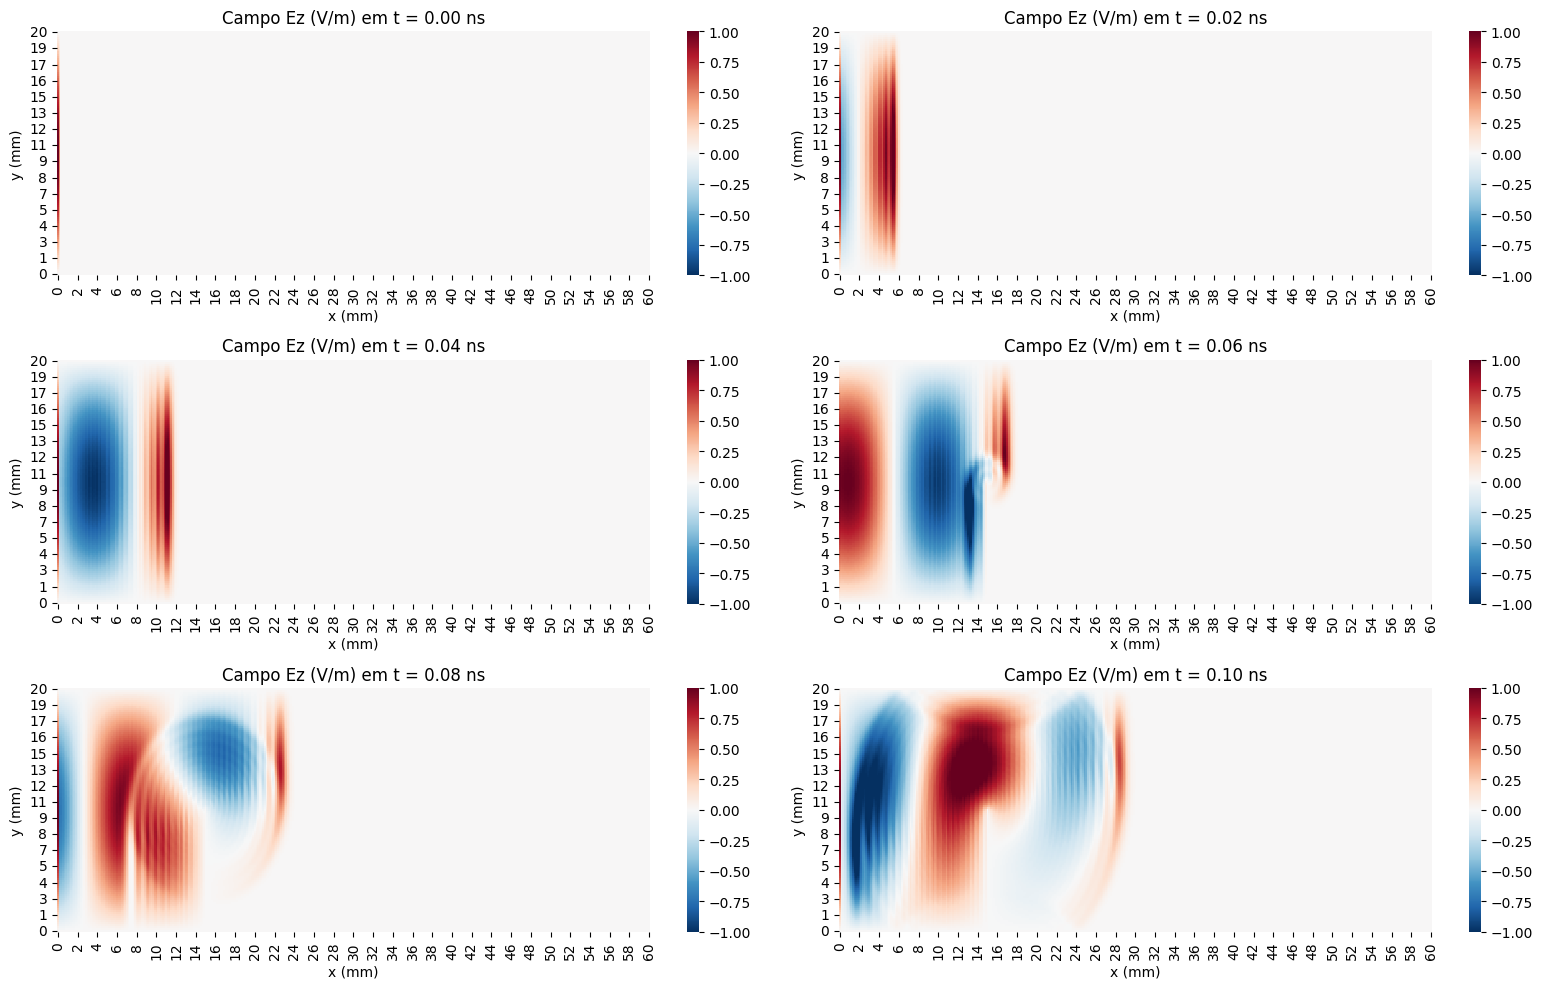

In [58]:
fig, axes = plt.subplots(3, 2, figsize=(16, 10))

for i, ax in enumerate(axes.flat):
    sns.heatmap(Ez_snapshots[i].T, ax=ax, annot=False, cmap='RdBu_r',vmin=-1, vmax=1, center=0)
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    ax.set_title(f"Campo Ez (V/m) em t = {n_snapshots[i]*dt*1e9:.2f} ns")

    ticks_x = ax.get_xticks()
    labels_x = [f'{float(label.get_text()) * dx * 1000:.0f}' for label in ax.get_xticklabels()]
    ax.set_xticklabels(labels_x)

    ticks_y = ax.get_yticks()
    labels_y = [f'{float(label.get_text()) * dy * 1000:.0f}' for label in ax.get_yticklabels()]
    ax.set_yticklabels(labels_y)

    ax.invert_yaxis()

plt.tight_layout()
plt.show()

/tmp/ipykernel_52070/1409565819.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


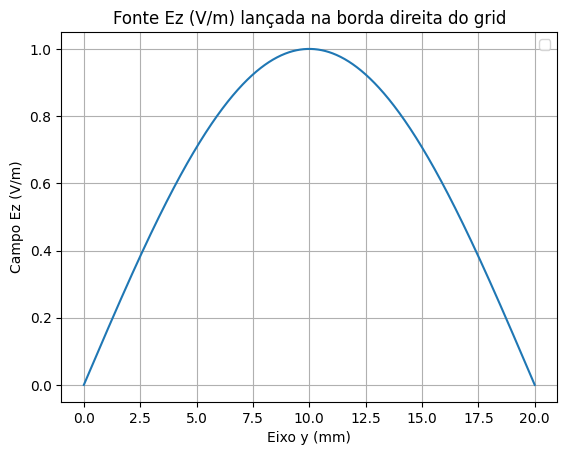

In [59]:
a = 20e-3
y_grid = np.linspace(0, a, 1000)

plt.plot(y_grid * 1000, np.sin(np.pi * y_grid / a))
plt.title(fr"Fonte Ez (V/m) lançada na borda direita do grid")
plt.xlabel("Eixo y (mm)")
plt.ylabel("Campo Ez (V/m)")
plt.grid()
plt.legend()

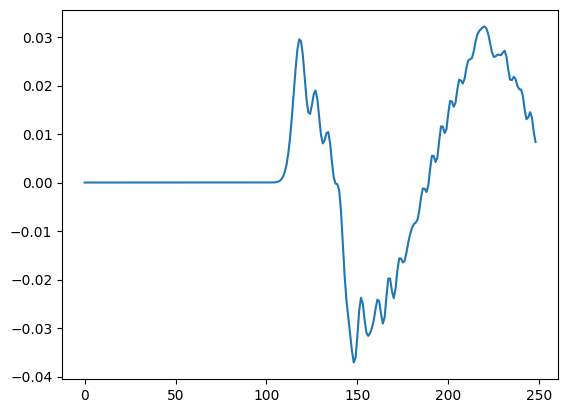

In [60]:
plt.plot(probe)

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft, fftfreq

# --- parâmetros físicos ---
eps = 8.854187817e-12  # Vacuum permittivity (F/m)
mu = 4 * np.pi * 1e-7  # Vacuum permeability (H/m)
vp = 1 / np.sqrt(eps * mu)

a = 20e-3
fcte1 = 1 / (2 * a * np.sqrt(eps * mu))
fcte2 = 2 / (2 * a * np.sqrt(eps * mu))

# f = (fcte1 + fcte2) / 2
min_lambda = vp / f  # comprimento de onda mínimo que preciso simular

dx = dy = 0.01 * min_lambda
Lx = 3 * a
Ly = a
Nx = int(Lx / dx)
Ny = int(Ly / dy)

dt = 0.99 / (vp * np.sqrt((1/dx**2) + (1/dy**2)))
Nt = 250
T = Nt * dt

dist_scat_egde = 15e-3
scat_length = 10e-3
cx, cy = Nx // 2, Ny // 2
scat_x, scat_y = int(dist_scat_egde / dx), Ny // 2
scat_range_x = range(scat_x, scat_x + int(scat_length / dx))

grid_x_Ez = np.linspace(0, Lx, Nx + 1)
grid_y_Ez = np.linspace(0, Ly, Ny + 1)
grid_t_Ez = np.linspace(0, T, Nt + 1)

grid_x_Hx = np.linspace(0, Lx, Nx + 1)
grid_y_Hx = np.linspace(dy/2, Ly - dy/2, Ny)
grid_t_Hx = np.linspace(dt/2, T - dt/2, Nt)

grid_x_Hy = np.linspace(dx/2, Lx - dx/2, Nx)
grid_y_Hy = np.linspace(0, Ly, Ny + 1)
grid_t_Hy = np.linspace(dt/2, T - dt/2, Nt)

# --- campos ---
Ez_curr = Ez_next = Ez_prev = np.zeros((grid_x_Ez.shape[0], grid_y_Ez.shape[0]))
Hx_curr = Hx_next = np.zeros((grid_x_Hx.shape[0], grid_y_Hx.shape[0]))
Hy_curr = Hy_next = np.zeros((grid_x_Hy.shape[0], grid_y_Hy.shape[0]))

# ponta de prova para coletar pontos
px, py = scat_x - 10, scat_y
probe = []

# valores do tempo para salvar os snapshots e montar os heatmaps
n_snapshots = np.linspace(0, Nt- 2, 6, dtype=int)
Ez_incident_snapshots = []

for n in range(Nt-1):
    # fonte onda planar
    source_senoidal = np.sin(2 * np.pi * f * n * dt)
    source_senoidal_standing = np.sin(np.pi * grid_y_Ez / a) * np.cos(2 * np.pi * f * n * dt)

    # aplica em todos os Y em X = 0 (left boundary plane wave)
    Ez_curr[0, :] = source_senoidal_standing

    Hx_next[:, :] = Hx_curr[:, :] - (dt/(mu*dy)) * (
        Ez_curr[:, 1:] - Ez_curr[:, :-1]
    )

    Hy_next[:, :] = Hy_curr[:, :] + (dt/(mu*dx)) * (
        Ez_curr[1:, :] - Ez_curr[:-1, :]
    )

    Ez_next[1:-1, 1:-1] = Ez_curr[1:-1, 1:-1] + (dt/eps) * (
        (Hy_next[1:, 1:-1] - Hy_next[:-1, 1:-1]) / dx -
        (Hx_next[1:-1, 1:] - Hx_next[1:-1, :-1]) / dy
    )

    # PEC no objeto scatter
    # Ez_next[scat_range_x, scat_y] = 0

    # PEC nas extremidades
    Ez_next[-1, :] = 0
    Ez_next[:, -1] = 0
    Ez_next[:, 0]  = 0

    # salva na ponta de prova
    probe.append(Ez_next[px,py])

    # atualiza os campos para o próximo passo
    Ez_curr = Ez_next.copy()
    Ez_prev = Ez_curr.copy()
    Hx_curr = Hx_next.copy()
    Hy_curr = Hy_next.copy()

    # salva para os snapshots
    if n in n_snapshots:
        Ez_incident_snapshots.append(Ez_curr.copy())


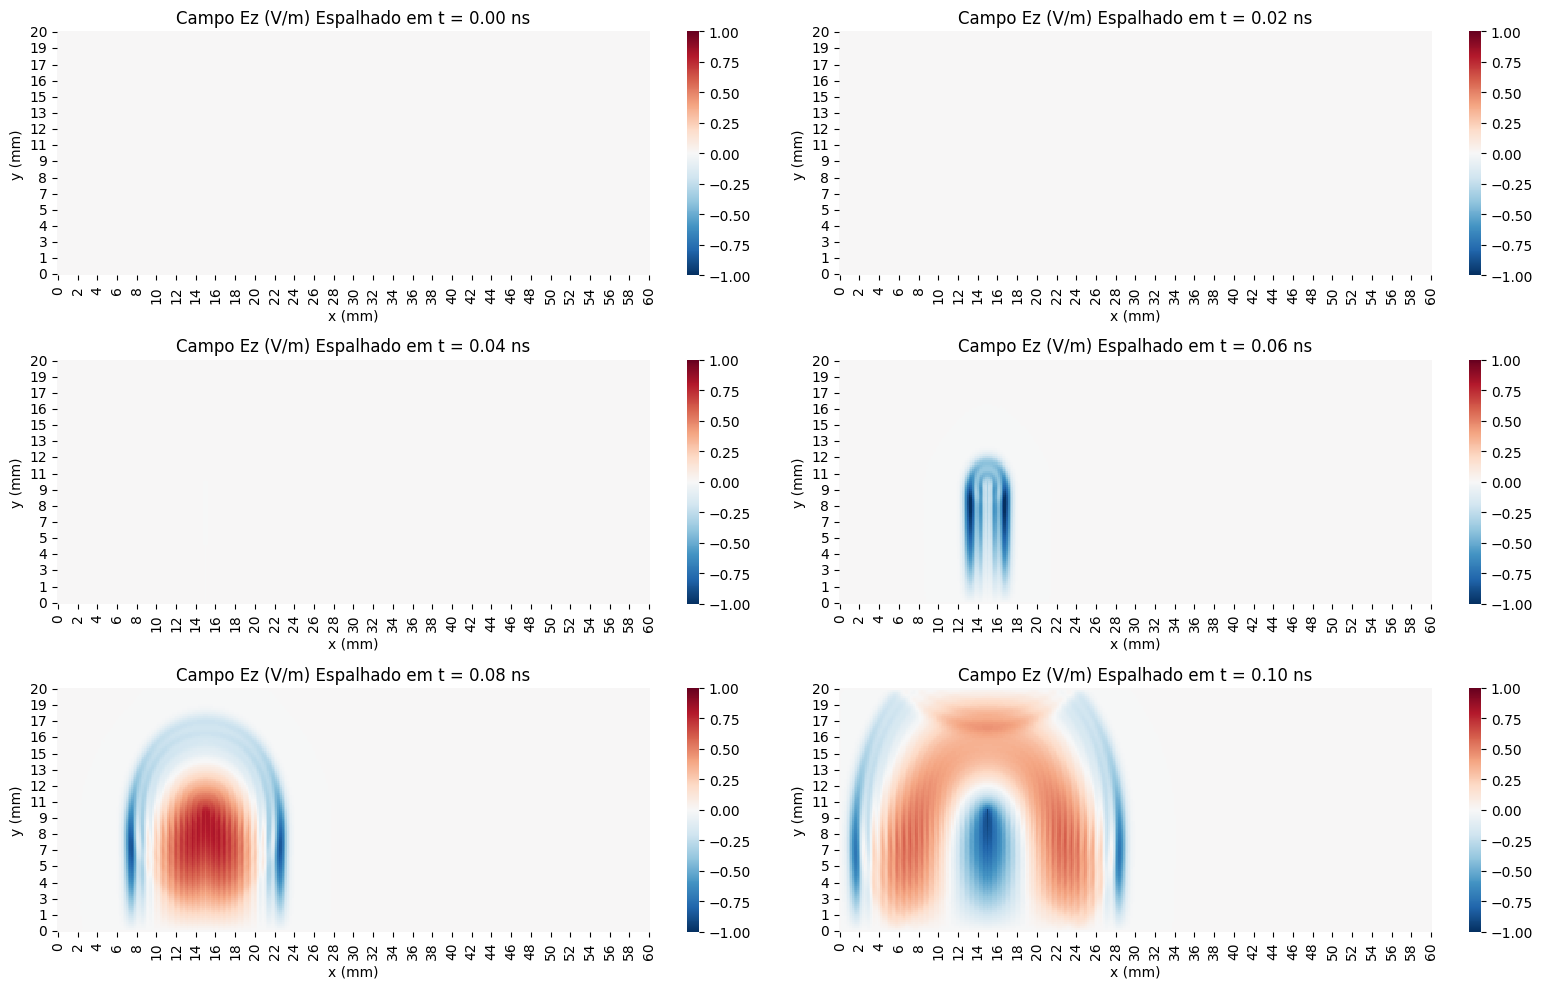

In [62]:
fig, axes = plt.subplots(3, 2, figsize=(16, 10))

for i, ax in enumerate(axes.flat):
    sns.heatmap((Ez_snapshots[i] - Ez_incident_snapshots[i]).T, ax=ax, annot=False, cmap='RdBu_r',vmin=-1, vmax=1, center=0)
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    ax.set_title(f"Campo Ez (V/m) Espalhado em t = {n_snapshots[i]*dt*1e9:.2f} ns")

    ticks_x = ax.get_xticks()
    labels_x = [f'{float(label.get_text()) * dx * 1000:.0f}' for label in ax.get_xticklabels()]
    ax.set_xticklabels(labels_x)

    ticks_y = ax.get_yticks()
    labels_y = [f'{float(label.get_text()) * dy * 1000:.0f}' for label in ax.get_yticklabels()]
    ax.set_yticklabels(labels_y)

    ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [63]:
1.2 * fcte2

np.float64(17987547480.630173)